In [1]:
#Import neccessary python modules

%matplotlib inline
import numpy as np
from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from scipy.ndimage import median_filter
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from scipy.interpolate import UnivariateSpline 
from scipy.interpolate import interp1d 

from IPython.display import display, HTML

import copy

from scipy.optimize import minimize

import pandas as pd

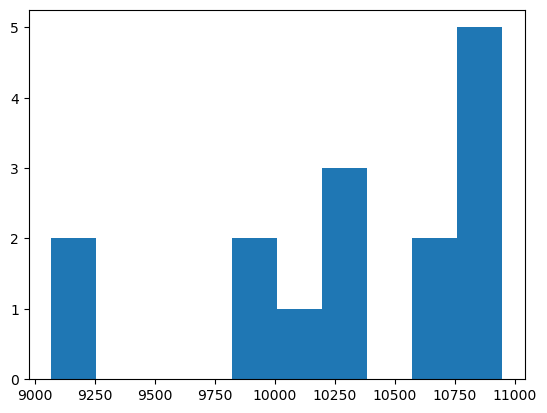

10308.89278987
580.030372666211


In [17]:



velocities = [14784.29710721, 11287.65029163, 10586.11517877, 
              11526.80175968, 11498.61160391, 11602.28467904, 9067.20569467, 
              11103.68821553, 11602.70884884, 11337.93325133, 11872.20138955, 
              11477.93650304, 11681.88232343, 11477.7132209, 11433.86970311, 
              10279.93006518, 9995.7924797, 9995.7924797, 8865.91752118, 7225.19847525, 
              12233.9161033, 11304.76596071, 12007.88852526, 11840.35357055, 10839.53100954, 
              10226.27181016, 11198.9996524, 11004.25211293, 12669.05902375, 11386.98366249, 
              11477.24870826, 11206.47967839, 11051.17784297, 11620.17436391, 24814.34990328, 
              10945.8744697, 10926.8253899, 12679.06951192, 8535.46836959, 10140.84973122, 6809.07685735, 
              5364.41396783, 12134.29089335, 12026.2610968, 11326.79500972, 11720.67243176, 10308.89278987, 
              11361.50934928, 11139.06348167, 11529.45737662, 9144.7881881, 11273.32858822, 11738.94970968, 
              8263.76180212, 12209.48099003, 10674.16316328, 11532.96658513, 11446.65170617, 10823.63965452, 
              11336.12294945, 10923.09688652, 7749.41107317]
vs = []
for i in range(len(velocities)):
    if not (velocities[i] > 11000 or velocities[i] < 9000):
        vs.append(velocities[i])
        

velocities = vs

plt.hist(velocities)
plt.show()
print(np.median(velocities))
print(np.std(velocities))

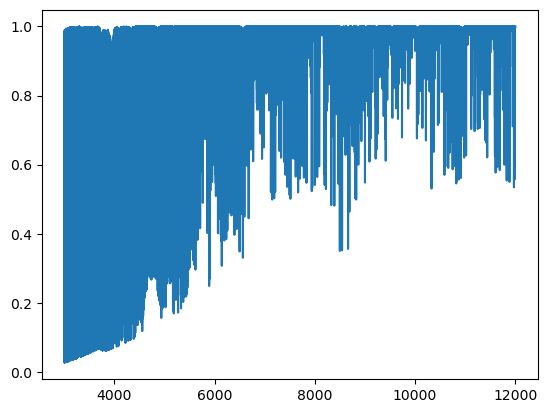

In [2]:
folder = 'P:/ASTR211/Synthetic Spectra/my_spectra/' # This is the direct folder with the files

# Goes through and finds each file in a designated folder

files = [folder + file for file in os.listdir(folder) if '.FIT' in file]
# Goes through and finds each file with a specific pattern in the folder, alternate method (puts in a list)
# This method is architecture dependent (e.g. the order for a MacOs M3 will be different to a Windows HP)


for file in files:
    hdul = fits.open(file)
    header = hdul[0].header
    hdul.close()

hdul = fits.open(files[0])
data = hdul[0].data
data1 = hdul[1].data
header = hdul[0].header
hdul.close()
# print(header)



# extracting wavelength data 
data = np.array(data1)
flux = []
wavelength = []
for tup in data:
    flux.append(float(tup[2]))
    wavelength.append(float(tup[0]))
    

plt.plot(wavelength, flux)
plt.show()



In [20]:
def interpolate_spectra(template_spectrum, old_spectrum):
    
    template_wavelength = template_spectrum[0]
    old_wavelength, old_flux = old_spectrum

    interp_flux = np.interp(template_wavelength, old_wavelength, old_flux)

    return interp_flux

def chi_squared(model_spectrum, real_spectrum):
    model_flux = model_spectrum[1]
    real_flux = real_spectrum[1]
    
    return sum([(real - model)**2 / model for real, model in zip(real_flux, model_flux)])

def get_spectrum(file):
    hdul = fits.open(file)
    data = hdul[1].data
    hdul.close()
    flux = []
    wavelength = []
    for tup in data:
#         print(tup[2])
#         print(tup[0])
        flux.append(float(tup[2]))
        wavelength.append(float(tup[0]))
#     print(len(wavelength), len(flux))
    return [wavelength, flux]

star_spectrum = np.load('star_spectrum.npy', allow_pickle=True)
corrected_wavelength, star_flux = star_spectrum

folder = 'P:/ASTR211/Synthetic Spectra/my_spectra/'

files = [folder + file for file in os.listdir(folder) if '.FIT' in file] # getting our synthetic spectra
min_chi = np.inf
min_i = 0
for i, file in enumerate(files):
    
    model_spectrum = get_spectrum(file)# get model spectrum
    interp_flux = interpolate_spectra([corrected_wavelength], model_spectrum)
    
    real_spectrum = [corrected_wavelength, star_flux]
    model_spectrum = [corrected_wavelength, interp_flux]
#     print(len(real_spectrum[1]))
#     print((model_spectrum))
    chi2 = chi_squared(model_spectrum, real_spectrum)
    
    if chi2 < min_chi:
        min_chi = chi2
        min_i = i

print(min_i, min_chi)


20 5645.692151089557


In [21]:
print(files[20])

P:/ASTR211/Synthetic Spectra/my_spectra/M_p5750g4.5z-1.00t1.0_a0.00c0.00n0.00o0.00r0.00s0.00_VIS.spec.FITS.zip
